In [1]:
import numpy as np
import opt_einsum as oe
import matplotlib.pyplot as plt
import scipy as sp

from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal import integration_scheme
import quant_rotor.CCC_integration_methods.Dense.thermofield_boltz_funcs as bz

from quant_rotor.Hamiltonian_models.Dense.heisenberg_operators import heisenberg_operators
from quant_rotor.Hamiltonian_models.Dense.hamiltonian import hamiltonian_dense as ham
from quant_rotor.Hamiltonian_models.Dense.rotor_operators import rotor_operators
from quant_rotor.Hamiltonian_models.Dense.NO_transfrorm import NO_transform

from quant_rotor.Hamiltonian_models.Dense.combine_hamiltonian import combine_hamiltonian as ham_comb

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_periodic import t_periodic

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_guess import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state, amplitute_energy, intermediate_normalisation

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_sub_class import (
    QuantumSimulation,
    SimulationParams,
    TensorData,
)

from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import U as U_stat

In [2]:
np.set_printoptions(precision=8)
np.set_printoptions(suppress=True)
np.set_printoptions(linewidth=np.inf)
np.set_printoptions(threshold=np.inf)

# Rotor TF

In [3]:
site = 3
state = 3

state_2 = state**2

g = 0.1

periodic = True

In [4]:
K, V = rotor_operators(state, g)
H = ham(site, K, V, periodic)

eig_val, eig_vec = np.linalg.eigh(H)

In [5]:
U, _ = bz.thermofield_change_of_basis(K)

I = np.eye(state)

K_R = oe.contract('pq,mw->pmqw', K, I,  optimize='optimal').reshape(state_2, state_2)

K_U = U.T @ K_R @ U

V_tensor = V.reshape(state, state, state, state)

V_R = oe.contract('pqrs,mw,nv->pmqnrwsv', V_tensor, I, I,  optimize='optimal').reshape(state_2**2, state_2**2)

V_grouped = V_R.reshape(state**2, state**2, state**2, state**2)

V_U = oe.contract('Mi,Wj,ijab,aN,bV->MWNV', U.T, U.T, V_grouped, U, U, optimize='optimal').reshape(state_2**2, state_2**2)

In [6]:
H_U = ham(site, K_U, V_U, periodic)
H_R = ham(site, K_R, V_R, periodic)

In [7]:
eig_val_U, eig_vec_U = np.linalg.eigh(H_U)
eig_val_R, eig_vec_R = np.linalg.eigh(H_R)

In [8]:
print("ED:", eig_val)
print("TF_R:", eig_val_R)
print("TF_U:", eig_val_U)

ED: [-0.02002103  0.78532516  0.9451335   0.9451335   1.0908337   1.09868512  1.09868512  1.81628033  1.86771243  1.86771243  1.95        1.95        1.95        2.05        2.1         2.1         2.1037407   2.13228757  2.13228757  3.          3.          3.00131488  3.00131488  3.0048665   3.0048665   3.0091663   3.01467484]
TF_R: [-0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103 -0.02002103  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.78532516  0.9451335   0.

In [9]:
p = state_2
a = state_2 - 1
i = 1

In [10]:
t_a_i_tensor = np.full((site, a, i), 0, dtype=complex)
t_ab_ij_tensor = np.full((site, site, a, a, i, i), 0, dtype=complex)

In [11]:
for x in range(site):
    for A in range(1, state):
            t_a_i_tensor[x, A + state * A - 1] = 1

In [12]:
# t_1_exact = t_1_amplitude_guess_ground_state(state_2, site, eig_vec_TF, eig_val_TF)
# t_2_exact = t_2_amplitude_guess_ground_state(state_2, site, eig_vec_TF, eig_val_TF)

In [13]:
t_final = 20

In [16]:
time_TF_R, energy_TF_R, one_max_TF_R, two_max_TF_R = integration_scheme(site, state_2, K_R, V_R.reshape(state_2, state_2, state_2, state_2), V_R.reshape(state_2, state_2, state_2, state_2), t_init=0,t_final=t_final,nof_points=10000, periodic=periodic, import_guess=True, t_1_import=t_a_i_tensor, t_2_import=t_ab_ij_tensor)

In [34]:
time_TF_U, energy_TF_U, one_max_TF_U, two_max_TF_U = integration_scheme(site, state_2, K_U, V_U.reshape(state_2, state_2, state_2, state_2), V_U.reshape(state_2, state_2, state_2, state_2), t_init=0,t_final=12,nof_points=10000)

In [18]:
time, energy, one_max, two_max = integration_scheme(site, state, K, V.reshape(state, state, state, state), V.reshape(state, state, state, state), t_init=0,t_final=t_final,nof_points=10000)

In [19]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF_R])

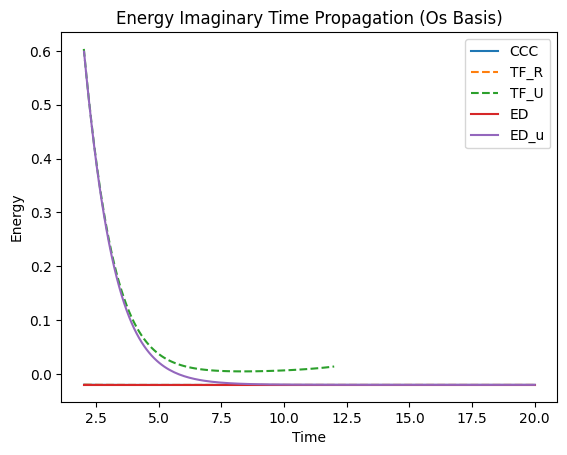

CCC (-0.020164695302658787+0j)
TF_U (0.014031488933074874+0j)
TF_R (-0.020164695302658787+0j)
ED -0.0200210268095415
ED_u -0.02002093670411428


In [35]:
plt.plot(time[time > 2], energy[time > 2], label=f"CCC")
plt.plot(time_TF_R[time_TF_R > 2], energy_TF_R[time_TF_R > 2], label=f"TF_R", linestyle='--')
plt.plot(time_TF_U[time_TF_U > 2], energy_TF_U[time_TF_U > 2], label=f"TF_U", linestyle='--')
plt.plot(time[time > 2], np.ones_like(time)[time > 2] * eig_val[0], label=f"ED")
plt.plot(time_TF_R[time_TF_R > 2], ED_U_val[time_TF_R > 2], label=f"ED_u")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

print("CCC", energy[-1])
print("TF_U", energy_TF_U[-1])
print("TF_R", energy_TF_R[-1])
print("ED", eig_val[0])
print("ED_u", ED_U_val[-1])

In [36]:
print("TF_U", energy_TF_U[0])
print("TF_R", energy_TF_R[0])

TF_U (2+0j)
TF_R 0j


In [44]:
K_R.real

array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [45]:
K_U

array([[ 0.66666667+0.j, -0.        +0.j,  0.47140452+0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j],
       [-0.        +0.j,  1.        +0.j, -0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.47140452+0.j, -0.        +0.j,  0.33333333+0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j,  1.        +0.j,  0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.

In [43]:
K_R[0, 1:] @ t_a_i_tensor[0]

array([0.+0.j])

In [39]:
t_a_i_tensor[0].real

array([[0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.]])

In [40]:
U

array([[ 0.57735027, -0.        , -0.81649658,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  1.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  1.        ,  0.        ,  0.        ,  0.        ],
       [ 0.57735027, -0.70710678,  0.40824829,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  1.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  0.        ,  1.   